# Heightmap 기반 Packing RL (Colab)

실측 카탈로그를 기반으로, 매 에피소드마다 **조금씩 크기가 다른 변형 물체**를 샘플링해서 학습하는 강화학습 버전입니다.

핵심 변경점
- 바구니 크기 고정: **150 × 120 × 75**
- 최대 물체 수 고정: **6**
- 상태는 **height map + 전역 통계 + 물체 feature**
- 행동은 **2-Policy**
  - 순서 선택: 어떤 물체를 먼저 놓을지
  - 배치 선택: `(rotation, x, y)` 중 feasible action 선택
- reward는 Height map 휴리스틱을 바탕으로 재설계
- 디버깅용 3D plot 유지


In [1]:

import os
import math
import json
import random
from dataclasses import dataclass
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# =========================
# Seed / device
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# =========================
# Config
# =========================
CONFIG = {
    "basket_size": (145, 115, 75),
    "grid_size": 5,               # 150x120 -> 30x24 grid
    "episodes": 8000,
    "max_objects": 6,
    "base_support_threshold": 0.70,
    "order_lr": 2e-4,
    "place_lr": 2e-4,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_eps": 0.2,
    "update_epochs": 4,
    "entropy_coef": 0.01,
    "value_coef": 0.5,
    "max_grad_norm": 1.0,
    "save_every": 200,
    "checkpoint_path": "checkpoint_heightmap_two_policy_candidate_split.pth",
    "hidden_dim": 192,
    "candidate_top_k": 24,
    "candidate_score_scale": 12.0,
    "eval_every": 500,
    "eval_episodes": 24,

    "num_envs": 16,
    "minibatch_size": 256,
    "max_steps_per_env": 8,
    "use_amp": torch.cuda.is_available(),
}

BASE_CATALOG = [
    {"name": "공룡 블럭", "size": (95, 80, 35), "durability": 4},
    {"name": "카라멜1", "size": (70, 45, 20), "durability": 1},
    {"name": "카라멜2", "size": (70, 45, 20), "durability": 1},
    {"name": "나비 블럭", "size": (80, 50, 40), "durability": 3},
    {"name": "아이셔", "size": (110, 75, 40), "durability": 2},
    {"name": "이클립스", "size": (80, 50, 15), "durability": 5},
]


CURRICULUM_STAGES = [
    {"end_ep": 1500,  "stage_name": "fixed-3",   "object_count_probs": {3: 1.00},                         "jitter_xy": 2, "jitter_z": 1, "support_threshold": 0.84},
    {"end_ep": 3000,  "stage_name": "3to4",      "object_count_probs": {3: 0.70, 4: 0.30},               "jitter_xy": 3, "jitter_z": 2, "support_threshold": 0.81},
    {"end_ep": 4500,  "stage_name": "4to5",      "object_count_probs": {3: 0.15, 4: 0.55, 5: 0.30},     "jitter_xy": 4, "jitter_z": 2, "support_threshold": 0.78},
    {"end_ep": 6000,  "stage_name": "5to6",      "object_count_probs": {4: 0.20, 5: 0.50, 6: 0.30},     "jitter_xy": 3, "jitter_z": 2, "support_threshold": 0.74},
    {"end_ep": 8000, "stage_name": "mixed-3to6","object_count_probs": {3: 0.18, 4: 0.30, 5: 0.30, 6: 0.22}, "jitter_xy": 2, "jitter_z": 1, "support_threshold": 0.70},
]

CURRICULUM_BLEND_WIDTH = 0.10
CURRICULUM_MASTERY_WEIGHT = 0.08

def _normalize_count_probs(prob_dict):
    counts = list(range(3, CONFIG["max_objects"] + 1))
    probs = np.array([float(prob_dict.get(c, 0.0)) for c in counts], dtype=np.float32)
    if probs.sum() <= 0:
        probs[0] = 1.0
    probs = probs / probs.sum()
    return counts, probs

def _estimate_mastery(recent_stats=None):
    if not recent_stats:
        return 0.0
    placed_ratio = float(recent_stats.get("placed_ratio", 0.0))
    compact_fill = float(recent_stats.get("compact_fill", 0.0))
    feasible_ratio = float(recent_stats.get("feasible_ratio", placed_ratio))
    mastery = 0.60 * placed_ratio + 0.25 * compact_fill + 0.15 * feasible_ratio
    return float(np.clip(mastery, 0.0, 1.0))

def _blend_stage(stage_a, stage_b, alpha):
    alpha = float(np.clip(alpha, 0.0, 1.0))
    counts = sorted(set(stage_a["object_count_probs"]) | set(stage_b["object_count_probs"]))
    probs = {}
    for c in counts:
        pa = float(stage_a["object_count_probs"].get(c, 0.0))
        pb = float(stage_b["object_count_probs"].get(c, 0.0))
        probs[int(c)] = (1.0 - alpha) * pa + alpha * pb

    _, norm_probs = _normalize_count_probs(probs)
    probs = {c: float(p) for c, p in zip(list(range(3, CONFIG["max_objects"] + 1)), norm_probs)}

    return {
        "stage_name": f"{stage_a['stage_name']}->{stage_b['stage_name']}({alpha:.2f})",
        "object_count_probs": probs,
        "jitter_xy": int(round((1.0 - alpha) * stage_a["jitter_xy"] + alpha * stage_b["jitter_xy"])),
        "jitter_z": int(round((1.0 - alpha) * stage_a["jitter_z"] + alpha * stage_b["jitter_z"])),
        "support_threshold": float((1.0 - alpha) * stage_a["support_threshold"] + alpha * stage_b["support_threshold"]),
    }

def get_curriculum_stage(ep: int, recent_stats=None):
    total_eps = max(1, CONFIG["episodes"] - 1)
    schedule_progress = ep / total_eps
    mastery = _estimate_mastery(recent_stats)
    effective_progress = float(np.clip(schedule_progress + CURRICULUM_MASTERY_WEIGHT * (mastery - 0.55), 0.0, 1.0))

    boundaries = [stage["end_ep"] / CONFIG["episodes"] for stage in CURRICULUM_STAGES]
    prev_boundary = 0.0
    for idx, boundary in enumerate(boundaries):
        if effective_progress <= boundary or idx == len(CURRICULUM_STAGES) - 1:
            current_stage = CURRICULUM_STAGES[idx]
            if idx == len(CURRICULUM_STAGES) - 1:
                return _blend_stage(CURRICULUM_STAGES[idx - 1], current_stage, 1.0) if idx > 0 else current_stage

            width = CURRICULUM_BLEND_WIDTH
            blend_start = max(prev_boundary, boundary - width)
            if effective_progress < blend_start or idx == 0:
                if idx == 0:
                    alpha = np.clip((effective_progress - prev_boundary) / max(1e-6, boundary - prev_boundary), 0.0, 1.0)
                    return _blend_stage(CURRICULUM_STAGES[0], CURRICULUM_STAGES[min(1, len(CURRICULUM_STAGES)-1)], 0.35 * alpha)
                return current_stage

            alpha = (effective_progress - blend_start) / max(1e-6, boundary - blend_start)
            return _blend_stage(current_stage, CURRICULUM_STAGES[idx + 1], alpha)

        prev_boundary = boundary

    return CURRICULUM_STAGES[-1]

def sample_episode_objects(stage_cfg, rng=None):
    if rng is None:
        rng = np.random

    counts, probs = _normalize_count_probs(stage_cfg["object_count_probs"])
    num_objects = int(rng.choice(counts, p=probs))
    chosen_idx = rng.choice(len(BASE_CATALOG), size=num_objects, replace=False)

    objects = []
    for local_idx, base_idx in enumerate(chosen_idx):
        base = BASE_CATALOG[int(base_idx)]
        sx, sy, sz = base["size"]
        jxy = int(stage_cfg["jitter_xy"])
        jz = int(stage_cfg["jitter_z"])

        nx = int(np.clip(sx + rng.randint(-jxy, jxy + 1), 18, CONFIG["basket_size"][0] - 5))
        ny = int(np.clip(sy + rng.randint(-jxy, jxy + 1), 18, CONFIG["basket_size"][1] - 5))
        nz = int(np.clip(sz + rng.randint(-jz, jz + 1), 10, CONFIG["basket_size"][2] - 5))

        dura = int(np.clip(base["durability"] + rng.randint(-1, 2), 1, 5))

        objects.append({
            "episode_index": int(local_idx),
            "base_index": int(base_idx),
            "name": base["name"],
            "size": (nx, ny, nz),
            "durability": dura,
        })
    return objects




device: cpu


In [2]:

# =========================
# Geometry / Environment
# =========================

def unique_rotations(size):
    return sorted(set(__import__("itertools").permutations(size, 3)))

def size_to_rpy(original, rotated):
    ox, oy, oz = original
    mapping = {
        (ox, oy, oz): (0, 0, 0),
        (ox, oz, oy): (90, 0, 0),
        (oy, ox, oz): (0, 0, 90),
        (oy, oz, ox): (0, 90, 0),
        (oz, ox, oy): (90, 90, 0),
        (oz, oy, ox): (0, 90, 90),
    }
    return mapping.get(tuple(rotated), (0, 0, 0))

def overlap_area_2d(ax, ay, aw, ad, bx, by, bw, bd):
    ox = max(0, min(ax + aw, bx + bw) - max(ax, bx))
    oy = max(0, min(ay + ad, by + bd) - max(ay, by))
    return ox * oy

@dataclass(frozen=True)
class Placement:
    episode_index: int
    base_index: int
    name: str
    original_size: tuple
    size: tuple
    position: tuple
    durability: int
    support_ratio: float
    rotation_rpy: tuple

class HeightMap:
    def __init__(self, basket_size, grid_size):
        self.bx, self.by, self.bz = basket_size
        self.grid = int(grid_size)
        self.gx = self.bx // self.grid
        self.gy = self.by // self.grid
        self.heights = np.zeros((self.gy, self.gx), dtype=np.int32)

    def copy(self):
        hm = HeightMap((self.bx, self.by, self.bz), self.grid)
        hm.heights = self.heights.copy()
        return hm

    def mm_to_cells_xy(self, w, d):
        return math.ceil(w / self.grid), math.ceil(d / self.grid)

    def cell_to_mm_xy(self, cx, cy):
        return cx * self.grid, cy * self.grid

    def region_stats(self, cx, cy, wc, dc):
        region = self.heights[cy:cy+dc, cx:cx+wc]
        base_h = int(region.max())
        support_cover = float(np.mean(region == base_h))
        roughness = float(region.max() - region.min())
        return {"base_h": base_h, "support_cover": support_cover, "roughness": roughness}

    def place(self, cx, cy, wc, dc, top_h):
        self.heights[cy:cy+dc, cx:cx+wc] = top_h

def boxes_intersect(p1, p2):
    x1, y1, z1 = p1.position
    w1, d1, h1 = p1.size
    x2, y2, z2 = p2.position
    w2, d2, h2 = p2.size
    overlap_x = (x1 < x2 + w2) and (x2 < x1 + w1)
    overlap_y = (y1 < y2 + d2) and (y2 < y1 + d1)
    overlap_z = (z1 < z2 + h2) and (z2 < z1 + h1)
    return overlap_x and overlap_y and overlap_z

def in_bounds(pos, size, basket):
    x, y, z = pos
    w, d, h = size
    bx, by, bz = basket
    return x >= 0 and y >= 0 and z >= 0 and (x + w) <= bx and (y + d) <= by and (z + h) <= bz

def total_item_volume(placements):
    return sum(p.size[0] * p.size[1] * p.size[2] for p in placements)

def used_height(placements):
    if not placements:
        return 0
    return max(p.position[2] + p.size[2] for p in placements)

def bounding_box_volume(placements):
    if not placements:
        return 0
    max_x = max(p.position[0] + p.size[0] for p in placements)
    max_y = max(p.position[1] + p.size[1] for p in placements)
    max_z = max(p.position[2] + p.size[2] for p in placements)
    return max_x * max_y * max_z

class PackingEnv:
    def __init__(self, basket_size, grid_size, support_threshold=0.70, max_objects=6, candidate_top_k=24):
        self.basket_size = basket_size
        self.grid_size = grid_size
        self.max_objects = max_objects
        self.support_threshold = support_threshold
        self.candidate_top_k = candidate_top_k
        self.heightmap = HeightMap(basket_size, grid_size)
        self.objects = []
        self.remaining = []
        self.placements = []
        self.cached_candidates = {}
        self.cached_ranked_candidates = {}

    def reset(self, objects, support_threshold=None):
        self.objects = [dict(obj) for obj in objects]
        self.remaining = list(range(len(objects)))
        self.placements = []
        self.heightmap = HeightMap(self.basket_size, self.grid_size)
        if support_threshold is not None:
            self.support_threshold = support_threshold
        self.cached_candidates = {}
        self.cached_ranked_candidates = {}
        self.prev_compact_fill = 0.0
        self.prev_height_ratio = 0.0
        self.prev_feasible_obj_ratio = 1.0
        return self.get_global_state()

    def exact_support_ratio(self, pos, size):
        x, y, z = pos
        w, d, _ = size
        if z == 0:
            return 1.0
        base_area = w * d
        support_area = 0
        for p in self.placements:
            px, py, pz = p.position
            pw, pd, ph = p.size
            if pz + ph != z:
                continue
            support_area += overlap_area_2d(x, y, w, d, px, py, pw, pd)
        return support_area / base_area if base_area > 0 else 0.0

    def durability_penalty(self, candidate):
        x, y, z = candidate.position
        w, d, _ = candidate.size
        pen = 0.0
        for p in self.placements:
            px, py, pz = p.position
            pw, pd, ph = p.size
            if pz + ph != z:
                continue
            overlap = overlap_area_2d(x, y, w, d, px, py, pw, pd)
            if overlap <= 0:
                continue
            if candidate.durability > p.durability:
                pen += 1.8 * (candidate.durability - p.durability) * (overlap / max(1, w * d))
        return pen

    def validate_placement(self, pos, size):
        if not in_bounds(pos, size, self.basket_size):
            return False, 0.0, "out_of_bounds"

        x, y, z = pos
        w, d, h = size
        if z + h > self.basket_size[2]:
            return False, 0.0, "over_height"

        probe = Placement(
            episode_index=-1,
            base_index=-1,
            name="probe",
            original_size=size,
            size=size,
            position=pos,
            durability=1,
            support_ratio=0.0,
            rotation_rpy=(0, 0, 0),
        )

        if any(boxes_intersect(probe, p) for p in self.placements):
            return False, 0.0, "overlap"

        support = self.exact_support_ratio(pos, size)
        support = min(support, 1.0) if z > 0 else 1.0
        if support < self.support_threshold:
            return False, float(support), "insufficient_support"

        return True, float(support), "ok"

    def candidate_score(self, candidate):
        bx, by, bz = self.basket_size
        x, y, z = candidate.position
        w, d, h = candidate.size
        new_list = list(self.placements) + [candidate]

        compact_fill = total_item_volume(new_list) / max(1, bounding_box_volume(new_list))
        current_top = used_height(self.placements)
        new_top = used_height(new_list)
        height_increase = max(0, new_top - current_top)

        wall_bonus = 0.0
        if x == 0:
            wall_bonus += 0.5
        if y == 0:
            wall_bonus += 0.5
        if z == 0:
            wall_bonus += 1.0
        if x + w == bx:
            wall_bonus += 0.2
        if y + d == by:
            wall_bonus += 0.2

        centered_penalty = 0.002 * (x + y)
        top_gap_penalty = 0.05 * max(0, (z + h) - 0.85 * bz)
        dura_pen = self.durability_penalty(candidate)

        base_area = w * d
        flat_bonus = 0.012 * (base_area / max(1, h))

        wc, dc = self.heightmap.mm_to_cells_xy(w, d)
        cx = x // self.heightmap.grid
        cy = y // self.heightmap.grid
        roughness = 0.0
        if cx + wc <= self.heightmap.gx and cy + dc <= self.heightmap.gy:
            roughness = self.heightmap.region_stats(cx, cy, wc, dc)["roughness"]

        low_position_factor = 1.0 - min(1.0, z / max(1.0, float(bz)))
        durability_strength = (candidate.durability - 1) / 4.0
        durability_layer_bonus = 2.5 * durability_strength * low_position_factor
        weak_bottom_penalty = 1.8 * (1.0 - durability_strength) * low_position_factor

        support_margin = 0.0
        if self.support_threshold < 1.0:
            support_margin = (candidate.support_ratio - self.support_threshold) / max(1e-6, 1.0 - self.support_threshold)
        support_margin = float(np.clip(support_margin, 0.0, 1.0))

        score = 0.0
        score += 9.5 * compact_fill
        score += 0.9 * support_margin
        score += wall_bonus
        score += flat_bonus
        score += durability_layer_bonus
        score -= 0.18 * z
        score -= 0.08 * height_increase
        score -= centered_penalty
        score -= top_gap_penalty
        score -= 0.04 * roughness
        score -= dura_pen
        score -= weak_bottom_penalty
        return float(score)

    def _build_candidates_for_object(self, obj_idx):
        if obj_idx in self.cached_candidates:
            return self.cached_candidates[obj_idx]

        obj = self.objects[obj_idx]
        candidates = []
        for rot in unique_rotations(obj["size"]):
            w, d, h = rot
            wc, dc = self.heightmap.mm_to_cells_xy(w, d)
            if wc > self.heightmap.gx or dc > self.heightmap.gy:
                continue

            rot_rpy = size_to_rpy(obj["size"], rot)
            for cy in range(self.heightmap.gy - dc + 1):
                for cx in range(self.heightmap.gx - wc + 1):
                    stats = self.heightmap.region_stats(cx, cy, wc, dc)
                    z = stats["base_h"]
                    x, y = self.heightmap.cell_to_mm_xy(cx, cy)
                    pos = (x, y, z)

                    is_valid, support, _ = self.validate_placement(pos, rot)
                    if not is_valid:
                        continue

                    candidate = Placement(
                        episode_index=obj["episode_index"],
                        base_index=obj["base_index"],
                        name=obj["name"],
                        original_size=obj["size"],
                        size=rot,
                        position=pos,
                        durability=obj["durability"],
                        support_ratio=support,
                        rotation_rpy=rot_rpy,
                    )

                    score = self.candidate_score(candidate)
                    new_list = list(self.placements) + [candidate]
                    compact_fill = total_item_volume(new_list) / max(1, bounding_box_volume(new_list))
                    candidates.append({
                        "candidate": candidate,
                        "score": float(score),
                        "cx": int(cx),
                        "cy": int(cy),
                        "wc": int(wc),
                        "dc": int(dc),
                        "top_h": int(z + h),
                        "compact_fill": float(compact_fill),
                        "wall_contacts": int((x == 0) + (y == 0) + (x + w == self.basket_size[0]) + (y + d == self.basket_size[1])),
                    })

        self.cached_candidates[obj_idx] = candidates
        return candidates

    def _rank_candidates_for_object(self, obj_idx):
        if obj_idx in self.cached_ranked_candidates:
            return self.cached_ranked_candidates[obj_idx]

        candidates = list(self._build_candidates_for_object(obj_idx))
        if len(candidates) == 0:
            self.cached_ranked_candidates[obj_idx] = []
            return []

        candidates.sort(
            key=lambda c: (
                c["score"],
                c["candidate"].support_ratio,
                -c["candidate"].position[2],
                c["compact_fill"],
            ),
            reverse=True,
        )
        ranked = candidates[: self.candidate_top_k]
        self.cached_ranked_candidates[obj_idx] = ranked
        return ranked

    def get_feasible_object_mask(self):
        mask = np.zeros(self.max_objects, dtype=np.float32)
        for i in range(min(len(self.objects), self.max_objects)):
            if i in self.remaining and len(self._rank_candidates_for_object(i)) > 0:
                mask[i] = 1.0
        return mask

    def get_candidate_mask(self, obj_idx):
        mask = np.zeros(self.candidate_top_k, dtype=np.float32)
        ranked = self._rank_candidates_for_object(obj_idx)
        if len(ranked) > 0:
            mask[:len(ranked)] = 1.0
        return mask

    def get_candidate_feature_matrix(self, obj_idx):
        feat_dim = 12
        mat = np.zeros((self.candidate_top_k, feat_dim), dtype=np.float32)
        ranked = self._rank_candidates_for_object(obj_idx)
        if len(ranked) == 0:
            return mat

        scores = np.array([c["score"] for c in ranked], dtype=np.float32)
        smin, smax = float(scores.min()), float(scores.max())
        denom = max(1e-6, smax - smin)

        bx, by, bz = self.basket_size
        basket_floor = max(1.0, float(bx * by))
        basket_vol = max(1.0, float(bx * by * bz))

        for i, entry in enumerate(ranked):
            cand = entry["candidate"]
            x, y, z = cand.position
            w, d, h = cand.size
            score_norm = (entry["score"] - smin) / denom
            mat[i] = np.array([
                x / bx,
                y / by,
                z / bz,
                w / bx,
                d / by,
                h / bz,
                cand.support_ratio,
                score_norm,
                entry["compact_fill"],
                entry["top_h"] / bz,
                (w * d) / basket_floor,
                (w * d * h) / basket_vol,
            ], dtype=np.float32)
        return mat

    def get_global_state(self):
        num_total = max(1, len(self.objects))
        placed = len(self.placements)
        max_h = used_height(self.placements)
        fill_ratio = total_item_volume(self.placements) / max(1, self.basket_size[0] * self.basket_size[1] * max(1, max_h))
        remaining_ratio = len(self.remaining) / self.max_objects
        placed_ratio = placed / num_total
        height_ratio = max_h / self.basket_size[2]
        mean_height = float(self.heightmap.heights.mean()) / max(1.0, self.basket_size[2])
        std_height = float(self.heightmap.heights.std()) / max(1.0, self.basket_size[2])
        feasible_obj_ratio = float(self.get_feasible_object_mask().sum()) / self.max_objects
        return np.array([
            placed_ratio,
            remaining_ratio,
            fill_ratio,
            height_ratio,
            mean_height,
            std_height,
            feasible_obj_ratio,
            self.support_threshold,
        ], dtype=np.float32)

    def get_heightmap_tensor(self):
        return (self.heightmap.heights.astype(np.float32) / self.basket_size[2])[None, :, :]

    def get_object_feature_matrix(self):
        feat_dim = 10
        mat = np.zeros((self.max_objects, feat_dim), dtype=np.float32)
        bx, by, bz = self.basket_size
        for i in range(min(len(self.objects), self.max_objects)):
            obj = self.objects[i]
            sx, sy, sz = obj["size"]
            vol = sx * sy * sz
            base = sx * sy
            remaining_flag = 1.0 if i in self.remaining else 0.0
            feasible_flag = 1.0 if len(self._rank_candidates_for_object(i)) > 0 and i in self.remaining else 0.0
            mat[i] = np.array([
                sx / bx,
                sy / by,
                sz / bz,
                obj["durability"] / 5.0,
                vol / (bx * by * bz),
                base / (bx * by),
                max(sx, sy, sz) / max(self.basket_size),
                min(sx, sy, sz) / max(self.basket_size),
                remaining_flag,
                feasible_flag,
            ], dtype=np.float32)
        return mat

    def has_any_feasible_action(self):
        return bool(self.get_feasible_object_mask().sum() > 0)

    def step(self, obj_idx, candidate_idx):
        ranked = self._rank_candidates_for_object(obj_idx)
        candidate_idx = int(candidate_idx)

        if candidate_idx < 0 or candidate_idx >= len(ranked):
            return self.get_global_state(), -0.40, True, {
                "reason": "invalid_candidate_choice",
                "selector_reward": -0.20,
                "placement_reward": -0.20,
            }

        num_total = max(1, len(self.objects))
        prev_compact_fill = float(self.prev_compact_fill)
        prev_height_ratio = float(self.prev_height_ratio)
        prev_feasible_obj_ratio = float(self.prev_feasible_obj_ratio)

        match = ranked[candidate_idx]
        candidate = match["candidate"]

        self.placements.append(candidate)
        if obj_idx in self.remaining:
            self.remaining.remove(obj_idx)

        self.heightmap.place(match["cx"], match["cy"], match["wc"], match["dc"], match["top_h"])
        self.cached_candidates = {}
        self.cached_ranked_candidates = {}

        next_state = self.get_global_state()
        done = (len(self.remaining) == 0) or (not self.has_any_feasible_action())

        total_vol = total_item_volume(self.placements)
        current_h = max(1, used_height(self.placements))
        compact_fill = total_vol / max(1, self.basket_size[0] * self.basket_size[1] * current_h)
        height_ratio = current_h / self.basket_size[2]
        placed_ratio = len(self.placements) / num_total
        feasible_ratio = float(self.get_feasible_object_mask().sum()) / self.max_objects

        fill_gain = compact_fill - prev_compact_fill
        height_increase = max(0.0, height_ratio - prev_height_ratio)
        feasible_gain = feasible_ratio - prev_feasible_obj_ratio

        wall_bonus = 0.5 * float(candidate.position[0] == 0) + 0.5 * float(candidate.position[1] == 0)
        low_layer_bonus = (candidate.durability / 5.0) * (1.0 - candidate.position[2] / self.basket_size[2])
        score_norm = np.clip(match["score"] / max(1e-6, CONFIG["candidate_score_scale"]), -1.0, 1.0)

        selector_reward = 0.0
        selector_reward += 0.55 * (1.0 / num_total)
        selector_reward += 0.35 * feasible_ratio
        selector_reward += 0.30 * feasible_gain
        selector_reward += 0.25 * compact_fill

        placement_reward = 0.0
        placement_reward += 1.15 * fill_gain
        placement_reward += 0.18 * low_layer_bonus
        placement_reward += 0.10 * wall_bonus
        placement_reward += 0.15 * candidate.support_ratio
        placement_reward += 0.22 * score_norm
        placement_reward -= 0.32 * height_increase
        placement_reward -= 0.12 * (candidate.position[2] / self.basket_size[2])

        info = {
            "placement": candidate,
            "compact_fill": compact_fill,
            "used_height": current_h,
            "placed_count": len(self.placements),
            "total_count": len(self.objects),
            "placed_ratio": placed_ratio,
            "feasible_ratio": feasible_ratio,
            "support_ratio": candidate.support_ratio,
        }

        if done:
            unplaced_ratio = 1.0 - placed_ratio
            void_ratio = max(0.0, 1.0 - compact_fill)
            all_placed_bonus = 0.55 if len(self.remaining) == 0 else 0.0
            dead_end_penalty = 0.55 * unplaced_ratio if len(self.remaining) > 0 else 0.0

            selector_reward += 1.30 * placed_ratio
            selector_reward -= 0.90 * unplaced_ratio
            selector_reward -= dead_end_penalty
            selector_reward += all_placed_bonus

            placement_reward += 0.95 * compact_fill
            placement_reward -= 0.75 * void_ratio
            placement_reward += 0.35 * candidate.support_ratio

            info["void_ratio"] = void_ratio
            info["unplaced_ratio"] = unplaced_ratio

        total_reward = selector_reward + placement_reward

        self.prev_compact_fill = compact_fill
        self.prev_height_ratio = height_ratio
        self.prev_feasible_obj_ratio = feasible_ratio

        info["selector_reward"] = float(selector_reward)
        info["placement_reward"] = float(placement_reward)
        info["total_reward"] = float(total_reward)
        return next_state, float(total_reward), done, info

# =========================
# Debug visualization
# =========================
def cuboid_faces(position, size):
    x, y, z = position
    w, d, h = size
    c = np.array([
        [x, y, z],
        [x + w, y, z],
        [x + w, y + d, z],
        [x, y + d, z],
        [x, y, z + h],
        [x + w, y, z + h],
        [x + w, y + d, z + h],
        [x, y + d, z + h],
    ], dtype=float)
    return [
        [c[i] for i in [0, 1, 2, 3]],
        [c[i] for i in [4, 5, 6, 7]],
        [c[i] for i in [0, 1, 5, 4]],
        [c[i] for i in [2, 3, 7, 6]],
        [c[i] for i in [1, 2, 6, 5]],
        [c[i] for i in [0, 3, 7, 4]],
    ]

def draw_basket_wireframe(ax, basket):
    bx, by, bz = basket
    pts = np.array([
        [0, 0, 0], [bx, 0, 0], [bx, by, 0], [0, by, 0],
        [0, 0, bz], [bx, 0, bz], [bx, by, bz], [0, by, bz],
    ], dtype=float)
    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),
        (4, 5), (5, 6), (6, 7), (7, 4),
        (0, 4), (1, 5), (2, 6), (3, 7),
    ]
    for a, b in edges:
        ax.plot(*zip(pts[a], pts[b]), linewidth=1.1)

def visualize_solution(placements, basket, title="RL Packing Result"):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    colors = ["cyan", "orange", "lime", "violet", "gold", "salmon", "deepskyblue", "pink"]
    for idx, p in enumerate(placements):
        faces = cuboid_faces(p.position, p.size)
        poly = Poly3DCollection(faces, facecolors=colors[idx % len(colors)], edgecolors="k", alpha=0.72)
        ax.add_collection3d(poly)
        cx = p.position[0] + p.size[0] / 2.0
        cy = p.position[1] + p.size[1] / 2.0
        cz = p.position[2] + p.size[2] / 2.0
        ax.text(cx, cy, cz, f"{p.base_index}:{p.name}", fontsize=8)
    draw_basket_wireframe(ax, basket)
    bx, by, bz = basket
    ax.set_xlim(0, bx)
    ax.set_ylim(0, by)
    ax.set_zlim(0, bz)
    ax.set_box_aspect((bx, by, bz))
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_zlabel("Z (mm)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def build_plan_output(placements):
    result = []
    for p in placements:
        pos = (float(p.position[0]), float(p.position[1]), float(p.position[2]))
        rotation = tuple(int(v) for v in p.rotation_rpy)
        result.append((int(p.base_index), pos, rotation))
    return result


In [3]:

# =========================
# Networks / PPO utils
# =========================

class HeightMapEncoder(nn.Module):
    def __init__(self, gy, gx, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 48, kernel_size=3, padding=1),
            nn.GELU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(48 * 4 * 4, hidden_dim),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)

class ObjectSelectorNetwork(nn.Module):
    def __init__(self, state_dim, object_feat_dim, gy, gx, max_objects, hidden_dim=192):
        super().__init__()
        self.max_objects = max_objects
        self.map_encoder = HeightMapEncoder(gy, gx, hidden_dim)
        self.state_proj = nn.Sequential(nn.Linear(state_dim, hidden_dim), nn.GELU())
        self.object_proj = nn.Sequential(nn.Linear(object_feat_dim, hidden_dim), nn.GELU())
        self.logit_head = nn.Linear(hidden_dim * 3, 1)
        self.value_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, heightmap, state_vec, object_feat):
        map_feat = self.map_encoder(heightmap)
        state_feat = self.state_proj(state_vec)
        obj_feat = self.object_proj(object_feat)

        context = torch.cat([map_feat, state_feat], dim=-1)
        value = self.value_head(context)

        map_expand = map_feat.unsqueeze(1).expand(-1, self.max_objects, -1)
        state_expand = state_feat.unsqueeze(1).expand(-1, self.max_objects, -1)
        cat = torch.cat([map_expand, state_expand, obj_feat], dim=-1)
        logits = self.logit_head(cat).squeeze(-1)
        return logits, value.squeeze(-1)

class PlacementPolicyNetwork(nn.Module):
    def __init__(self, state_dim, object_feat_dim, candidate_feat_dim, gy, gx, top_k, hidden_dim=192):
        super().__init__()
        self.top_k = top_k
        self.map_encoder = HeightMapEncoder(gy, gx, hidden_dim)
        self.state_proj = nn.Sequential(nn.Linear(state_dim, hidden_dim), nn.GELU())
        self.object_proj = nn.Sequential(nn.Linear(object_feat_dim, hidden_dim), nn.GELU())
        self.candidate_proj = nn.Sequential(nn.Linear(candidate_feat_dim, hidden_dim), nn.GELU())

        self.context_proj = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim * 2),
            nn.GELU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
        )
        self.logit_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )
        self.value_head = nn.Linear(hidden_dim, 1)

    def forward(self, heightmap, state_vec, object_feat, candidate_feat):
        map_feat = self.map_encoder(heightmap)
        state_feat = self.state_proj(state_vec)
        obj_feat = self.object_proj(object_feat)
        context = self.context_proj(torch.cat([map_feat, state_feat, obj_feat], dim=-1))

        cand_feat = self.candidate_proj(candidate_feat)
        context_expand = context.unsqueeze(1).expand(-1, self.top_k, -1)
        logits = self.logit_head(torch.cat([context_expand, cand_feat], dim=-1)).squeeze(-1)
        value = self.value_head(context).squeeze(-1)
        return logits, value

def mask_logits(logits, mask):
    if logits.dtype == torch.float16:
        neg_large = -1e4
    else:
        neg_large = -1e9
    return logits.masked_fill(mask < 0.5, neg_large)

def compute_gae(rewards, values, dones, gamma, lam):
    adv = []
    gae = 0.0
    next_value = 0.0
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * next_value * (1.0 - dones[t]) - values[t]
        gae = delta + gamma * lam * (1.0 - dones[t]) * gae
        adv.append(gae)
        next_value = values[t]
    adv.reverse()
    adv = torch.tensor(adv, dtype=torch.float32, device=device)
    returns = adv + torch.tensor(values, dtype=torch.float32, device=device)
    return adv, returns

def normalize_adv(adv):
    if adv.numel() > 1:
        return (adv - adv.mean()) / (adv.std(unbiased=False) + 1e-8)
    return adv - adv.mean()


In [4]:

# =========================
# Train / inference
# =========================

def run_inference_once(order_model, placement_model, objects, support_threshold=0.70, greedy=True):
    env = PackingEnv(
        CONFIG["basket_size"],
        CONFIG["grid_size"],
        support_threshold=support_threshold,
        max_objects=CONFIG["max_objects"],
        candidate_top_k=CONFIG["candidate_top_k"],
    )
    state = env.reset(objects, support_threshold=support_threshold)
    total_reward = 0.0

    order_model.eval()
    placement_model.eval()

    while env.has_any_feasible_action():
        hm_t = torch.tensor(env.get_heightmap_tensor(), dtype=torch.float32, device=device).unsqueeze(0)
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        obj_feat_t = torch.tensor(env.get_object_feature_matrix(), dtype=torch.float32, device=device).unsqueeze(0)
        order_mask_t = torch.tensor(env.get_feasible_object_mask(), dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            order_logits, _ = order_model(hm_t, state_t, obj_feat_t)
            order_logits = mask_logits(order_logits, order_mask_t)
            if greedy:
                obj_idx = int(torch.argmax(order_logits, dim=-1).item())
            else:
                obj_idx = int(Categorical(logits=order_logits).sample().item())

            chosen_feat = obj_feat_t[:, obj_idx, :]
            cand_feat_t = torch.tensor(env.get_candidate_feature_matrix(obj_idx), dtype=torch.float32, device=device).unsqueeze(0)
            cand_mask_t = torch.tensor(env.get_candidate_mask(obj_idx), dtype=torch.float32, device=device).unsqueeze(0)

            place_logits, _ = placement_model(hm_t, state_t, chosen_feat, cand_feat_t)
            place_logits = mask_logits(place_logits, cand_mask_t)
            if greedy:
                cand_idx = int(torch.argmax(place_logits, dim=-1).item())
            else:
                cand_idx = int(Categorical(logits=place_logits).sample().item())

        state, reward, done, _ = env.step(obj_idx, cand_idx)
        total_reward += reward
        if done:
            break

    return env.placements, total_reward, build_plan_output(env.placements)


def make_env(stage, rng=None):
    objects = sample_episode_objects(stage, rng=rng)
    env = PackingEnv(
        CONFIG["basket_size"],
        CONFIG["grid_size"],
        support_threshold=stage["support_threshold"],
        max_objects=CONFIG["max_objects"],
        candidate_top_k=CONFIG["candidate_top_k"],
    )
    state = env.reset(objects, support_threshold=stage["support_threshold"])
    return env, state, objects


def evaluate(order_model, placement_model, num_episodes=24, seed_offset=2000, stage=None):
    if stage is None:
        stage = CURRICULUM_STAGES[-1]
    summary = run_test_suite(
        order_model,
        placement_model,
        num_episodes=num_episodes,
        stage=stage,
        seed_offset=seed_offset,
        greedy=True,
    )
    return {
        "mean_reward": summary["mean_reward"],
        "placed_ratio": summary["mean_packed_ratio"],
        "compact_fill": summary["mean_compact_fill"],
    }


def collect_parallel_rollout(order_model, placement_model, stage, num_envs, episode_base_seed=0):
    envs, states, objects_list = [], [], []
    for i in range(num_envs):
        rng = np.random.RandomState(SEED + episode_base_seed + i)
        env, state, objects = make_env(stage, rng=rng)
        envs.append(env)
        states.append(state)
        objects_list.append(objects)

    order_trajectories = [[] for _ in range(num_envs)]
    place_trajectories = [[] for _ in range(num_envs)]
    ep_rewards = [0.0 for _ in range(num_envs)]
    ep_infos = [{"placements": [], "objects": objects_list[i]} for i in range(num_envs)]

    order_model.train()
    placement_model.train()

    max_steps = CONFIG["max_steps_per_env"]
    for _ in range(max_steps):
        active_ids = [i for i, env in enumerate(envs) if env.has_any_feasible_action()]
        if not active_ids:
            break

        hm_batch = torch.tensor(
            np.stack([envs[i].get_heightmap_tensor() for i in active_ids], axis=0),
            dtype=torch.float32, device=device
        )
        state_batch = torch.tensor(
            np.stack([states[i] for i in active_ids], axis=0),
            dtype=torch.float32, device=device
        )
        obj_feat_batch = torch.tensor(
            np.stack([envs[i].get_object_feature_matrix() for i in active_ids], axis=0),
            dtype=torch.float32, device=device
        )
        order_mask_batch = torch.tensor(
            np.stack([envs[i].get_feasible_object_mask() for i in active_ids], axis=0),
            dtype=torch.float32, device=device
        )

        with torch.amp.autocast("cuda", enabled=CONFIG["use_amp"]):
            order_logits, order_values = order_model(hm_batch, state_batch, obj_feat_batch)
            order_logits = mask_logits(order_logits, order_mask_batch)
            order_dist = Categorical(logits=order_logits)
            order_actions = order_dist.sample()
            order_logprobs = order_dist.log_prob(order_actions)

        chosen_feat_list = []
        cand_feat_list = []
        cand_mask_list = []
        valid_env_ids = []
        valid_local_ids = []

        for local_idx, env_id in enumerate(active_ids):
            obj_idx = int(order_actions[local_idx].item())
            cand_mask = envs[env_id].get_candidate_mask(obj_idx)
            if cand_mask.sum() <= 0:
                continue
            chosen_feat_list.append(obj_feat_batch[local_idx, obj_idx, :].detach().cpu().numpy())
            cand_feat_list.append(envs[env_id].get_candidate_feature_matrix(obj_idx))
            cand_mask_list.append(cand_mask)
            valid_env_ids.append(env_id)
            valid_local_ids.append(local_idx)

        if not valid_env_ids:
            break

        place_hm_batch = torch.tensor(
            np.stack([envs[i].get_heightmap_tensor() for i in valid_env_ids], axis=0),
            dtype=torch.float32, device=device
        )
        place_state_batch = torch.tensor(
            np.stack([states[i] for i in valid_env_ids], axis=0),
            dtype=torch.float32, device=device
        )
        chosen_feat_batch = torch.tensor(
            np.stack(chosen_feat_list, axis=0),
            dtype=torch.float32, device=device
        )
        cand_feat_batch = torch.tensor(
            np.stack(cand_feat_list, axis=0),
            dtype=torch.float32, device=device
        )
        cand_mask_batch = torch.tensor(
            np.stack(cand_mask_list, axis=0),
            dtype=torch.float32, device=device
        )

        with torch.amp.autocast("cuda", enabled=CONFIG["use_amp"]):
            place_logits, place_values = placement_model(place_hm_batch, place_state_batch, chosen_feat_batch, cand_feat_batch)
            place_logits = mask_logits(place_logits, cand_mask_batch)
            place_dist = Categorical(logits=place_logits)
            place_actions = place_dist.sample()
            place_logprobs = place_dist.log_prob(place_actions)

        for j, env_id in enumerate(valid_env_ids):
            local_idx = valid_local_ids[j]
            obj_idx = int(order_actions[local_idx].item())
            cand_idx = int(place_actions[j].item())

            next_state, reward, done, info = envs[env_id].step(obj_idx, cand_idx)
            ep_rewards[env_id] += reward

            order_trajectories[env_id].append({
                "hm": hm_batch[local_idx].detach().cpu(),
                "state": state_batch[local_idx].detach().cpu(),
                "object_feat": obj_feat_batch[local_idx].detach().cpu(),
                "mask": order_mask_batch[local_idx].detach().cpu(),
                "action": obj_idx,
                "logprob": float(order_logprobs[local_idx].item()),
                "value": float(order_values[local_idx].item()),
                "reward": float(info["selector_reward"]),
                "done": float(done),
            })

            place_trajectories[env_id].append({
                "hm": place_hm_batch[j].detach().cpu(),
                "state": place_state_batch[j].detach().cpu(),
                "chosen_feat": chosen_feat_batch[j].detach().cpu(),
                "candidate_feat": cand_feat_batch[j].detach().cpu(),
                "mask": cand_mask_batch[j].detach().cpu(),
                "action": cand_idx,
                "logprob": float(place_logprobs[j].item()),
                "value": float(place_values[j].item()),
                "reward": float(info["placement_reward"]),
                "done": float(done),
            })

            states[env_id] = next_state
            if done or not envs[env_id].has_any_feasible_action():
                ep_infos[env_id] = {"placements": list(envs[env_id].placements), "objects": objects_list[env_id]}

    return order_trajectories, place_trajectories, ep_rewards, ep_infos


def flatten_trajectories(trajectories, kind="order"):
    all_entries = []
    for traj in trajectories:
        if len(traj) == 0:
            continue
        adv, returns = compute_gae(
            [t["reward"] for t in traj],
            [t["value"] for t in traj],
            [t["done"] for t in traj],
            CONFIG["gamma"],
            CONFIG["gae_lambda"],
        )
        adv = normalize_adv(adv)
        for i, t in enumerate(traj):
            entry = dict(t)
            entry["adv"] = adv[i].item()
            entry["ret"] = returns[i].item()
            all_entries.append(entry)
    return all_entries


def ppo_update_order(order_model, order_optimizer, scaler, entries):
    if not entries:
        return
    hm_batch = torch.stack([t["hm"] for t in entries]).to(device)
    state_batch = torch.stack([t["state"] for t in entries]).to(device)
    obj_feat_batch = torch.stack([t["object_feat"] for t in entries]).to(device)
    mask_batch = torch.stack([t["mask"] for t in entries]).to(device)
    action_batch = torch.tensor([t["action"] for t in entries], dtype=torch.long, device=device)
    old_logprob_batch = torch.tensor([t["logprob"] for t in entries], dtype=torch.float32, device=device)
    adv_batch = torch.tensor([t["adv"] for t in entries], dtype=torch.float32, device=device)
    ret_batch = torch.tensor([t["ret"] for t in entries], dtype=torch.float32, device=device)

    n = len(entries)
    mb = min(CONFIG["minibatch_size"], n)

    for _ in range(CONFIG["update_epochs"]):
        perm = torch.randperm(n, device=device)
        for start in range(0, n, mb):
            idx = perm[start:start + mb]
            order_optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=CONFIG["use_amp"]):
                logits, values = order_model(hm_batch[idx], state_batch[idx], obj_feat_batch[idx])
                logits = mask_logits(logits, mask_batch[idx])
                dist = Categorical(logits=logits)
                new_logprob = dist.log_prob(action_batch[idx])
                entropy = dist.entropy().mean()
                ratio = torch.exp(new_logprob - old_logprob_batch[idx])
                surr1 = ratio * adv_batch[idx]
                surr2 = torch.clamp(ratio, 1.0 - CONFIG["clip_eps"], 1.0 + CONFIG["clip_eps"]) * adv_batch[idx]
                policy_loss = -torch.min(surr1, surr2).mean()
                value_loss = nn.functional.mse_loss(values, ret_batch[idx])
                loss = policy_loss + CONFIG["value_coef"] * value_loss - CONFIG["entropy_coef"] * entropy
            scaler.scale(loss).backward()
            scaler.unscale_(order_optimizer)
            torch.nn.utils.clip_grad_norm_(order_model.parameters(), CONFIG["max_grad_norm"])
            scaler.step(order_optimizer)
            scaler.update()


def ppo_update_place(placement_model, place_optimizer, scaler, entries):
    if not entries:
        return
    hm_batch = torch.stack([t["hm"] for t in entries]).to(device)
    state_batch = torch.stack([t["state"] for t in entries]).to(device)
    chosen_feat_batch = torch.stack([t["chosen_feat"] for t in entries]).to(device)
    candidate_feat_batch = torch.stack([t["candidate_feat"] for t in entries]).to(device)
    mask_batch = torch.stack([t["mask"] for t in entries]).to(device)
    action_batch = torch.tensor([t["action"] for t in entries], dtype=torch.long, device=device)
    old_logprob_batch = torch.tensor([t["logprob"] for t in entries], dtype=torch.float32, device=device)
    adv_batch = torch.tensor([t["adv"] for t in entries], dtype=torch.float32, device=device)
    ret_batch = torch.tensor([t["ret"] for t in entries], dtype=torch.float32, device=device)

    n = len(entries)
    mb = min(CONFIG["minibatch_size"], n)

    for _ in range(CONFIG["update_epochs"]):
        perm = torch.randperm(n, device=device)
        for start in range(0, n, mb):
            idx = perm[start:start + mb]
            place_optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=CONFIG["use_amp"]):
                logits, values = placement_model(
                    hm_batch[idx],
                    state_batch[idx],
                    chosen_feat_batch[idx],
                    candidate_feat_batch[idx],
                )
                logits = mask_logits(logits, mask_batch[idx])
                dist = Categorical(logits=logits)
                new_logprob = dist.log_prob(action_batch[idx])
                entropy = dist.entropy().mean()
                ratio = torch.exp(new_logprob - old_logprob_batch[idx])
                surr1 = ratio * adv_batch[idx]
                surr2 = torch.clamp(ratio, 1.0 - CONFIG["clip_eps"], 1.0 + CONFIG["clip_eps"]) * adv_batch[idx]
                policy_loss = -torch.min(surr1, surr2).mean()
                value_loss = nn.functional.mse_loss(values, ret_batch[idx])
                loss = policy_loss + CONFIG["value_coef"] * value_loss - CONFIG["entropy_coef"] * entropy
            scaler.scale(loss).backward()
            scaler.unscale_(place_optimizer)
            torch.nn.utils.clip_grad_norm_(placement_model.parameters(), CONFIG["max_grad_norm"])
            scaler.step(place_optimizer)
            scaler.update()


def train():
    dry_env = PackingEnv(
        CONFIG["basket_size"],
        CONFIG["grid_size"],
        max_objects=CONFIG["max_objects"],
        candidate_top_k=CONFIG["candidate_top_k"],
    )
    gy, gx = dry_env.heightmap.gy, dry_env.heightmap.gx
    state_dim = 8
    object_feat_dim = 10
    candidate_feat_dim = 12

    order_model = ObjectSelectorNetwork(
        state_dim, object_feat_dim, gy, gx,
        CONFIG["max_objects"], hidden_dim=CONFIG["hidden_dim"]
    ).to(device)
    placement_model = PlacementPolicyNetwork(
        state_dim, object_feat_dim, candidate_feat_dim, gy, gx,
        CONFIG["candidate_top_k"], hidden_dim=CONFIG["hidden_dim"]
    ).to(device)

    order_optimizer = optim.Adam(order_model.parameters(), lr=CONFIG["order_lr"])
    place_optimizer = optim.Adam(placement_model.parameters(), lr=CONFIG["place_lr"])

    reward_history, avg_history = [], []
    eval_history = []
    placed_ratio_history = []
    compact_fill_history = []

    best_reward = -1e9
    best_outputs = None
    best_objects = None
    start_ep = 0

    if os.path.exists(CONFIG["checkpoint_path"]):
        ckpt = torch.load(CONFIG["checkpoint_path"], map_location=device)
        order_model.load_state_dict(ckpt["order_model"])
        placement_model.load_state_dict(ckpt["placement_model"])
        order_optimizer.load_state_dict(ckpt["order_optimizer"])
        place_optimizer.load_state_dict(ckpt["place_optimizer"])
        reward_history = ckpt.get("reward_history", [])
        avg_history = ckpt.get("avg_history", [])
        eval_history = ckpt.get("eval_history", [])
        placed_ratio_history = ckpt.get("placed_ratio_history", [])
        compact_fill_history = ckpt.get("compact_fill_history", [])
        best_reward = ckpt.get("best_reward", -1e9)
        start_ep = ckpt.get("episodes_done", len(reward_history))
        print("checkpoint loaded:", CONFIG["checkpoint_path"], "| start_ep:", start_ep)
    else:
        print("checkpoint not found -> start from scratch")

    recent = deque(reward_history[-20:], maxlen=20)
    recent_placed = deque(placed_ratio_history[-120:], maxlen=120)
    recent_fill = deque(compact_fill_history[-120:], maxlen=120)
    scaler = torch.amp.GradScaler("cuda", enabled=CONFIG["use_amp"])

    ep = start_ep
    while ep < CONFIG["episodes"]:
        stage_stats = {
            "placed_ratio": float(np.mean(recent_placed)) if len(recent_placed) > 0 else 0.0,
            "compact_fill": float(np.mean(recent_fill)) if len(recent_fill) > 0 else 0.0,
            "feasible_ratio": float(np.mean(recent_placed)) if len(recent_placed) > 0 else 0.0,
        }
        stage = get_curriculum_stage(ep, recent_stats=stage_stats)
        batch_eps = min(CONFIG["num_envs"], CONFIG["episodes"] - ep)

        order_trajs, place_trajs, ep_rewards, ep_infos = collect_parallel_rollout(
            order_model, placement_model, stage, batch_eps, episode_base_seed=100000 + ep * 17
        )

        order_entries = flatten_trajectories(order_trajs, kind="order")
        place_entries = flatten_trajectories(place_trajs, kind="place")

        ppo_update_order(order_model, order_optimizer, scaler, order_entries)
        ppo_update_place(placement_model, place_optimizer, scaler, place_entries)

        for local_i in range(batch_eps):
            total_reward = ep_rewards[local_i]
            placements = ep_infos[local_i]["placements"]
            objects = ep_infos[local_i]["objects"]

            placed_ratio = len(placements) / max(1, len(objects))
            compact_fill = total_item_volume(placements) / max(
                1, CONFIG["basket_size"][0] * CONFIG["basket_size"][1] * max(1, used_height(placements))
            )

            recent.append(total_reward)
            recent_placed.append(placed_ratio)
            recent_fill.append(compact_fill)

            reward_history.append(total_reward)
            avg_history.append(float(np.mean(recent)))
            placed_ratio_history.append(float(placed_ratio))
            compact_fill_history.append(float(compact_fill))

            if total_reward > best_reward:
                best_reward = total_reward
                best_outputs = list(placements)
                best_objects = list(objects)

            global_ep = ep + local_i
            if global_ep % 20 == 0:
                print(
                    f"ep {global_ep:4d} | reward {total_reward:7.3f} | avg20 {avg_history[-1]:7.3f} | "
                    f"placed {len(placements):2d}/{len(objects):2d} | ratio {placed_ratio:5.2f} | "
                    f"stage {stage['stage_name'][:18]:>18s} | best {best_reward:7.3f}"
                )

        ep += batch_eps

        if ep % CONFIG["eval_every"] == 0:
            eval_result = evaluate(
                order_model,
                placement_model,
                num_episodes=CONFIG["eval_episodes"],
                seed_offset=2000 + ep,
                stage=CURRICULUM_STAGES[-1],
            )
            eval_history.append((ep, eval_result["mean_reward"], eval_result["placed_ratio"], eval_result["compact_fill"]))
            print(
                f"[eval] ep {ep:4d} | mean_reward {eval_result['mean_reward']:.3f} | "
                f"placed_ratio {eval_result['placed_ratio']:.3f} | compact_fill {eval_result['compact_fill']:.3f}"
            )

        if ep % CONFIG["save_every"] == 0 or ep >= CONFIG["episodes"]:
            torch.save({
                "order_model": order_model.state_dict(),
                "placement_model": placement_model.state_dict(),
                "order_optimizer": order_optimizer.state_dict(),
                "place_optimizer": place_optimizer.state_dict(),
                "reward_history": reward_history,
                "avg_history": avg_history,
                "eval_history": eval_history,
                "placed_ratio_history": placed_ratio_history,
                "compact_fill_history": compact_fill_history,
                "best_reward": best_reward,
                "episodes_done": ep,
            }, CONFIG["checkpoint_path"])
            print("checkpoint saved:", CONFIG["checkpoint_path"], "| episodes_done:", ep)

    return order_model, placement_model, reward_history, avg_history, eval_history, best_outputs, best_objects


def run_test_suite(order_model, placement_model, num_episodes=48, stage=None, seed_offset=9000, greedy=True):
    if stage is None:
        stage = CURRICULUM_STAGES[-1]

    result_rows = []
    order_model.eval()
    placement_model.eval()

    for e in range(num_episodes):
        rng = np.random.RandomState(SEED + seed_offset + e)
        objects = sample_episode_objects(stage, rng=rng)
        placements, total_reward, plan_output = run_inference_once(
            order_model, placement_model, objects,
            support_threshold=stage["support_threshold"],
            greedy=greedy,
        )
        packed_count = len(placements)
        max_h = max(1, used_height(placements))
        compact_fill = total_item_volume(placements) / max(1, CONFIG["basket_size"][0] * CONFIG["basket_size"][1] * max_h)
        result_rows.append({
            "episode": e,
            "reward": total_reward,
            "packed_count": packed_count,
            "num_objects": len(objects),
            "packed_ratio": packed_count / max(1, len(objects)),
            "compact_fill": compact_fill,
            "objects": objects,
            "placements": placements,
            "plan_output": plan_output,
        })

    rewards = [r["reward"] for r in result_rows]
    packed_ratios = [r["packed_ratio"] for r in result_rows]
    compact_fills = [r["compact_fill"] for r in result_rows]
    best_row = max(result_rows, key=lambda r: (r["packed_ratio"], r["reward"], r["compact_fill"]))

    summary = {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "mean_packed_ratio": float(np.mean(packed_ratios)),
        "mean_compact_fill": float(np.mean(compact_fills)),
        "best_row": best_row,
        "all_rows": result_rows,
    }
    return summary


checkpoint not found -> start from scratch
ep    0 | reward   1.868 | avg20   1.868 | placed  2/ 3 | ratio  0.67 | stage fixed-3->3to4(0.00 | best   1.868
ep   20 | reward   4.648 | avg20   3.110 | placed  3/ 3 | ratio  1.00 | stage fixed-3->3to4(0.02 | best   4.884
ep   40 | reward   2.092 | avg20   3.005 | placed  2/ 3 | ratio  0.67 | stage fixed-3->3to4(0.03 | best   4.884
ep   60 | reward   3.798 | avg20   3.398 | placed  3/ 3 | ratio  1.00 | stage fixed-3->3to4(0.03 | best   4.884
ep   80 | reward   4.554 | avg20   3.841 | placed  3/ 3 | ratio  1.00 | stage fixed-3->3to4(0.05 | best   5.586
ep  100 | reward   0.201 | avg20   3.142 | placed  1/ 3 | ratio  0.33 | stage fixed-3->3to4(0.05 | best   5.586
ep  120 | reward   4.140 | avg20   3.511 | placed  3/ 3 | ratio  1.00 | stage fixed-3->3to4(0.05 | best   5.586
ep  140 | reward   2.283 | avg20   3.571 | placed  2/ 3 | ratio  0.67 | stage fixed-3->3to4(0.06 | best   5.586
ep  160 | reward   2.061 | avg20   3.406 | placed  2/ 3 | rat

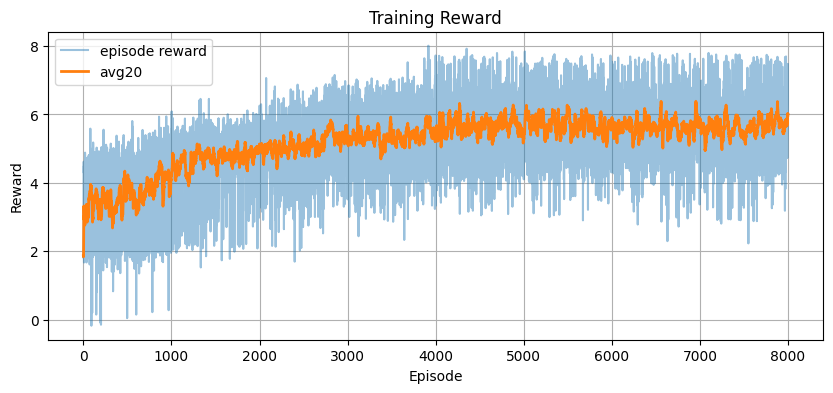

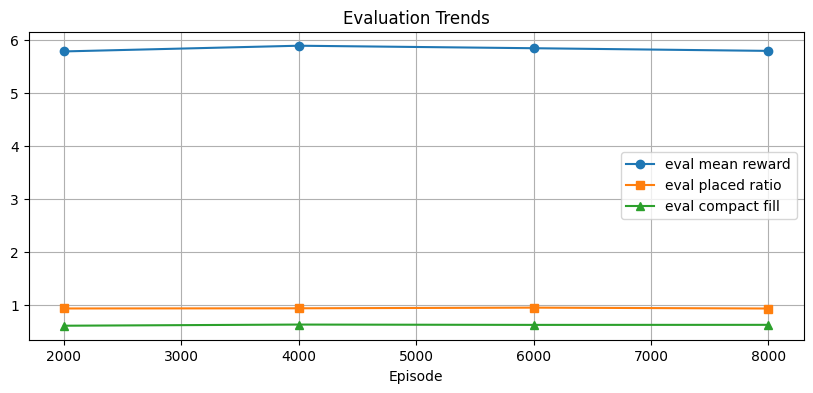

best training case plan_output:
[(4, (0.0, 0.0, 0.0), (0, 0, 90)), (5, (75.0, 0.0, 0.0), (0, 0, 90)), (0, (0.0, 0.0, 40.0), (0, 0, 90)), (3, (85.0, 0.0, 14.0), (90, 90, 0)), (1, (85.0, 90.0, 0.0), (0, 90, 0)), (2, (125.0, 0.0, 0.0), (90, 90, 0))]


C:\Users\82107\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82107\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82107\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49492 (\N{HANGUL SYLLABLE SYEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82107\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82107\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47549

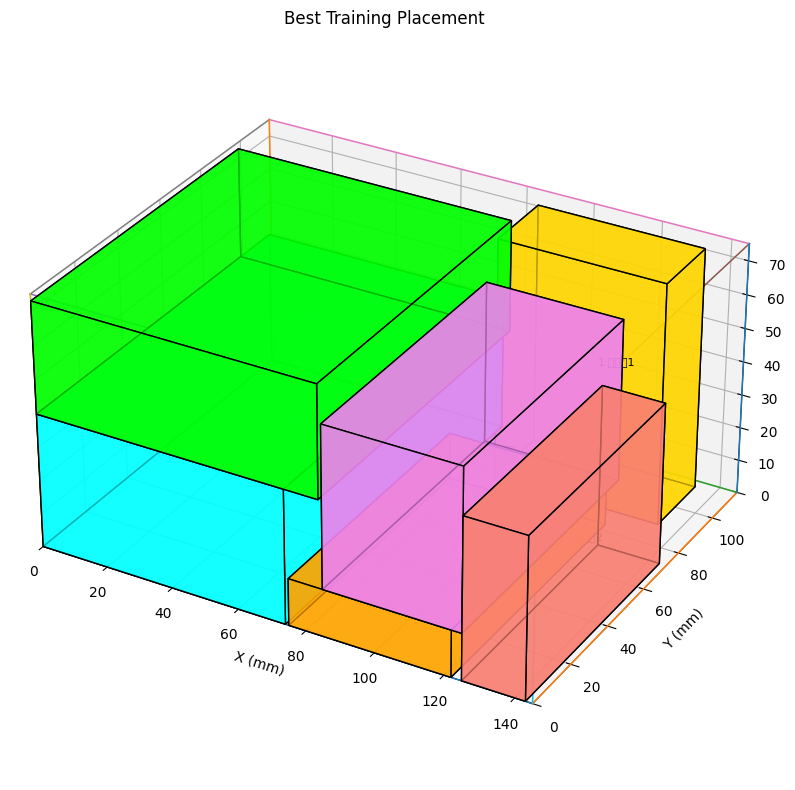

In [5]:

# =========================
# Training cell
# =========================

order_model, placement_model, reward_history, avg_history, eval_history, best_outputs, best_objects = train()

plt.figure(figsize=(10, 4))
plt.plot(reward_history, alpha=0.45, label="episode reward")
plt.plot(avg_history, linewidth=2, label="avg20")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Reward")
plt.legend()
plt.grid(True)
plt.show()

if len(eval_history) > 0:
    eval_eps = [x[0] for x in eval_history]
    eval_rewards = [x[1] for x in eval_history]
    eval_packed = [x[2] for x in eval_history]
    eval_fill = [x[3] for x in eval_history]

    plt.figure(figsize=(10, 4))
    plt.plot(eval_eps, eval_rewards, marker="o", label="eval mean reward")
    plt.plot(eval_eps, eval_packed, marker="s", label="eval placed ratio")
    plt.plot(eval_eps, eval_fill, marker="^", label="eval compact fill")
    plt.xlabel("Episode")
    plt.title("Evaluation Trends")
    plt.grid(True)
    plt.legend()
    plt.show()

if best_outputs is not None and best_objects is not None:
    print("best training case plan_output:")
    print(build_plan_output(best_outputs))
    visualize_solution(best_outputs, CONFIG["basket_size"], "Best Training Placement")


Test summary
{
  "mean_reward": 5.7211,
  "std_reward": 0.9795,
  "mean_packed_ratio": 0.9385,
  "mean_compact_fill": 0.6234
}

Best test plan_output:
[(4, (0.0, 0.0, 0.0), (0, 0, 90)), (0, (0.0, 0.0, 41.0), (0, 0, 90)), (3, (85.0, 0.0, 0.0), (90, 90, 0)), (5, (125.0, 0.0, 0.0), (90, 90, 0)), (2, (85.0, 80.0, 0.0), (0, 90, 0)), (1, (85.0, 0.0, 52.0), (0, 0, 90))]


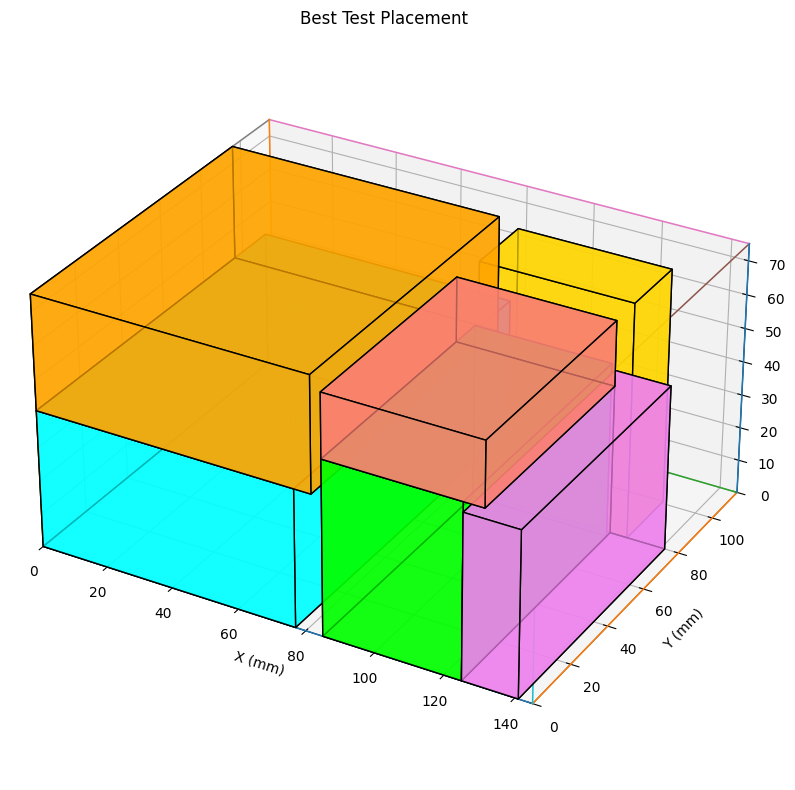

In [6]:

# =========================
# Test cell (separated from training)
# =========================

# Load trained checkpoint into fresh models if needed:
# ckpt = torch.load(CONFIG["checkpoint_path"], map_location=device)
# order_model.load_state_dict(ckpt["order_model"])
# placement_model.load_state_dict(ckpt["placement_model"])

test_stage = CURRICULUM_STAGES[-1]
test_summary = run_test_suite(order_model, placement_model, num_episodes=48, stage=test_stage, seed_offset=15000, greedy=True)

print("Test summary")
print(json.dumps({
    "mean_reward": round(test_summary["mean_reward"], 4),
    "std_reward": round(test_summary["std_reward"], 4),
    "mean_packed_ratio": round(test_summary["mean_packed_ratio"], 4),
    "mean_compact_fill": round(test_summary["mean_compact_fill"], 4),
}, ensure_ascii=False, indent=2))

best_test = test_summary["best_row"]
print("\nBest test plan_output:")
print(best_test["plan_output"])
visualize_solution(best_test["placements"], CONFIG["basket_size"], "Best Test Placement")
